# What is a PDF?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/what_is_pdf.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-20*

## Learning objectives

- Build intuition for how a histogram becomes a probability density function (PDF).
- See why a true PDF is normalized by both sample size **and** bin width.
- Compare a raw frequency histogram, a density-normalized PDF, and a kernel-smoothed estimate.
- Distinguish the PDF from its cumulative cousin, the CDF.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 5.0)

# Seed for reproducibility; use a Generator (modern numpy API).
SEED = 655
rng = np.random.default_rng(SEED)

We begin by drawing values from two Gaussian (normal) random variables:
`x` has length 75 and `y` has length 1000.

In [2]:
xinc = 0.5

x = rng.normal(0, 1, size=75)
y = rng.normal(0, 1, size=1000)

Next, we plot the `x` values along an arbitrary y-axis index.

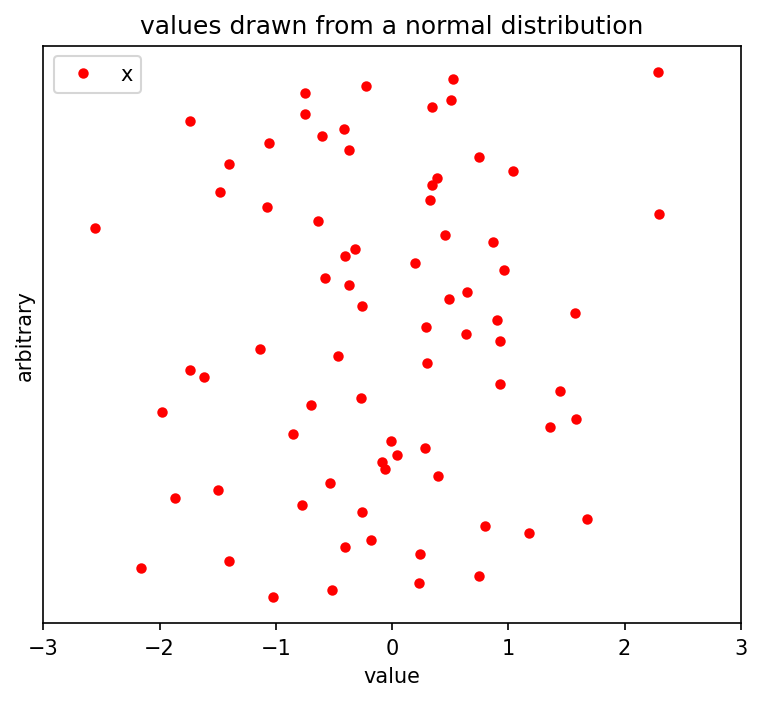

In [3]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.xlabel("value")
plt.ylabel("arbitrary")
plt.yticks([])
plt.title("values drawn from a normal distribution")
plt.xlim(-3, 3)

ax.plot(x, np.arange(np.size(x)), ".r", markersize=8, label="x")
ax.legend()
plt.show()

Now let's add the 1000 `y`-values to this scatter.

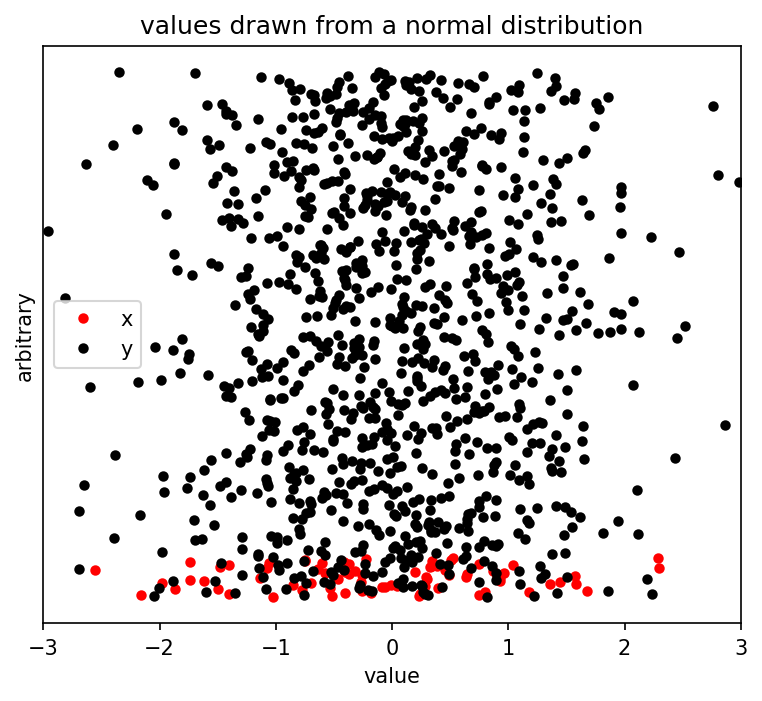

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.xlabel("value")
plt.ylabel("arbitrary")
plt.yticks([])
plt.title("values drawn from a normal distribution")
plt.xlim(-3, 3)

ax.plot(x, np.arange(np.size(x)), ".r", markersize=8, label="x")
ax.plot(y, np.arange(np.size(y)), ".k", markersize=8, label="y")
ax.legend()
plt.show()

## Making a histogram

Plotting raw data is incredibly important, but with many points it's hard to
see structure — how many black dots are hiding underneath other black dots? A
**histogram** discretizes the data into bins so we can count what's there.
Below we overlay vertical bin edges on the scatter.

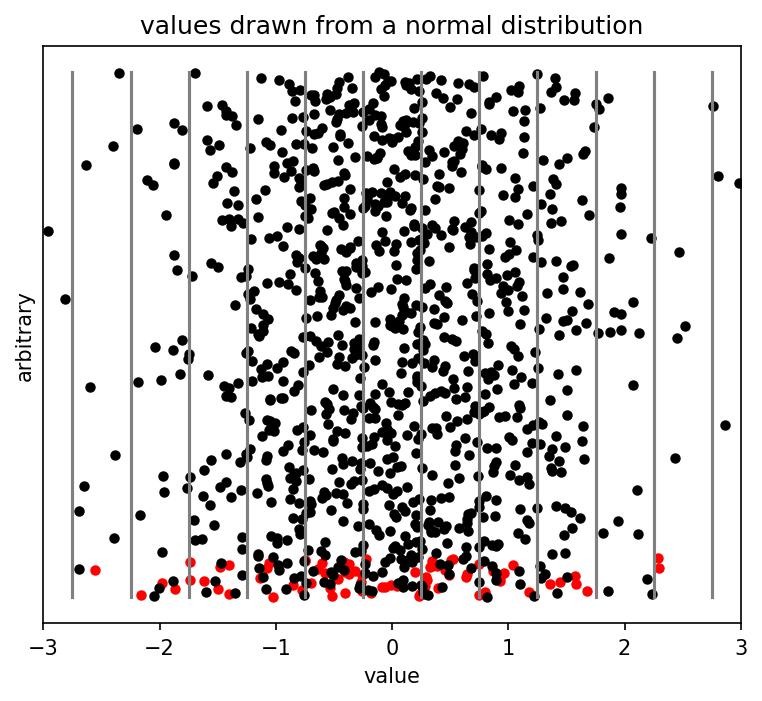

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.xlabel("value")
plt.ylabel("arbitrary")
plt.yticks([])
plt.title("values drawn from a normal distribution")
plt.xlim(-3, 3)

ax.plot(x, np.arange(np.size(x)), ".r", markersize=8, label="x")
ax.plot(y, np.arange(np.size(y)), ".k", markersize=8, label="y")

xbins = np.arange(-4, 4.5, xinc)
for val in xbins[1:]:
    ax.plot([val - 0.25, val - 0.25], [0, np.size(y)], "-", color="gray")
plt.show()

Now we count how many values fall in each bin and plot that count on the y-axis.

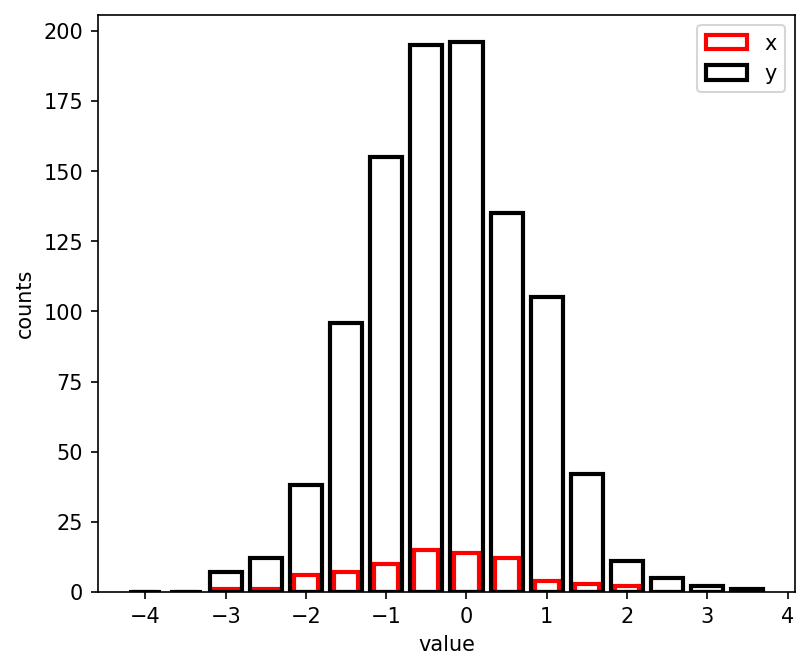

In [6]:
plt.figure()

hx = np.histogram(x, xbins)
hy = np.histogram(y, xbins)

plt.xlabel("value")
plt.ylabel("counts")

plt.bar(
    hx[1][:-1],
    hx[0],
    edgecolor="r",
    facecolor="none",
    width=0.3,
    label="x",
    linewidth=2,
)
plt.bar(
    hy[1][:-1],
    hy[0],
    edgecolor="k",
    facecolor="none",
    width=0.4,
    label="y",
    linewidth=2,
)
plt.legend()
plt.show()

## Normalizing the counts

The histogram looks great, and `y` clearly takes a Gaussian shape — but `x`
is hard to see because its counts are so small. If the goal is to **compare**
the two distributions, it helps to convert counts into units of *frequency*
(counts divided by the sample size).

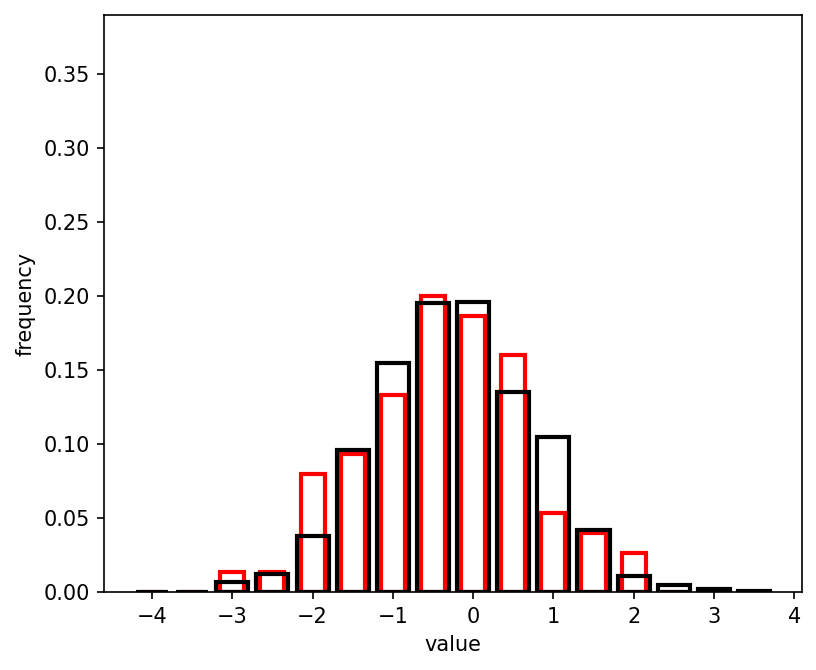

In [7]:
plt.figure()
plt.xlabel("value")
plt.ylabel("frequency")
plt.ylim(0, 0.39)

plt.bar(
    hx[1][:-1],
    hx[0].astype(float) / np.size(x),
    edgecolor="r",
    facecolor="none",
    width=0.3,
    linewidth=2,
)
plt.bar(
    hy[1][:-1],
    hy[0].astype(float) / np.size(y),
    edgecolor="k",
    facecolor="none",
    width=0.4,
    linewidth=2,
)
plt.show()

With `x` and `y` on the same footing (normalized to frequency) we can compare
the two and see they are in fact quite similar — though `x` is less Gaussian
looking because of its much smaller sample size.

One important thing to remember about histograms and frequency plots is that
they are *dependent on the bin size* you choose. What happens if we double
the bin width?

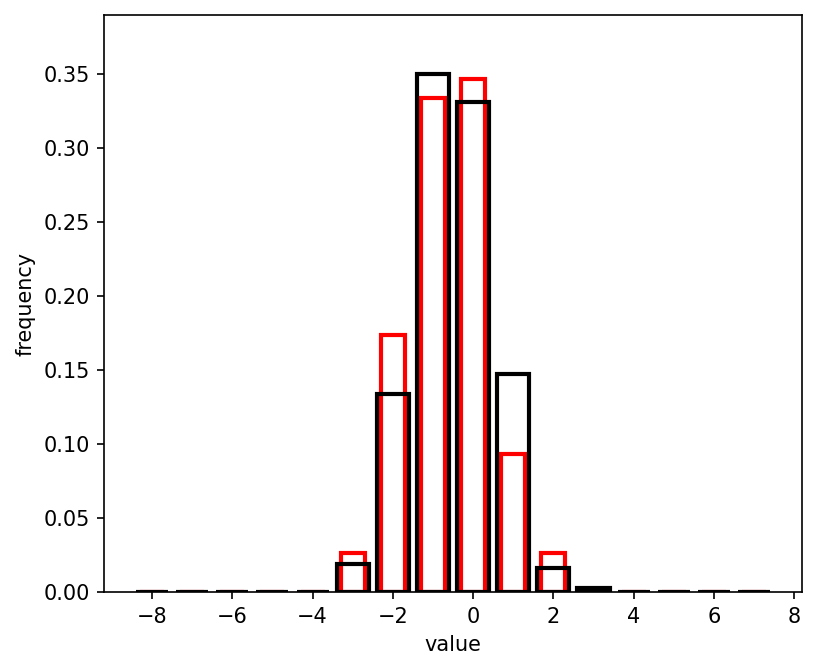

In [8]:
multiplicative_factor = 2.0
hx = np.histogram(x, xbins * multiplicative_factor)
hy = np.histogram(y, xbins * multiplicative_factor)

plt.figure()
plt.xlabel("value")
plt.ylabel("frequency")
plt.ylim(0, 0.39)

plt.bar(
    hx[1][:-1],
    hx[0].astype(float) / np.size(x),
    edgecolor="r",
    facecolor="none",
    width=0.3 * multiplicative_factor,
    linewidth=2,
)
plt.bar(
    hy[1][:-1],
    hy[0].astype(float) / np.size(y),
    edgecolor="k",
    facecolor="none",
    width=0.4 * multiplicative_factor,
    linewidth=2,
)
plt.show()

Notice that not only do the shapes of the histograms change, but the y-axis
scale changes too — the frequency is completely dependent on how big the bins
are. In many cases you don't want your plots to be a function of exactly how
much data you have. **PDF to the rescue!**

## Making this a true probability density function (PDF)

A true PDF is continuous, while histograms are discrete. To approach a true
PDF, we plot the per-bin frequency as a line curve. We also draw a larger
sample so the curve is smoother.

In [9]:
x = rng.normal(0, 1, size=10000)
y = rng.normal(0, 1, size=10000)

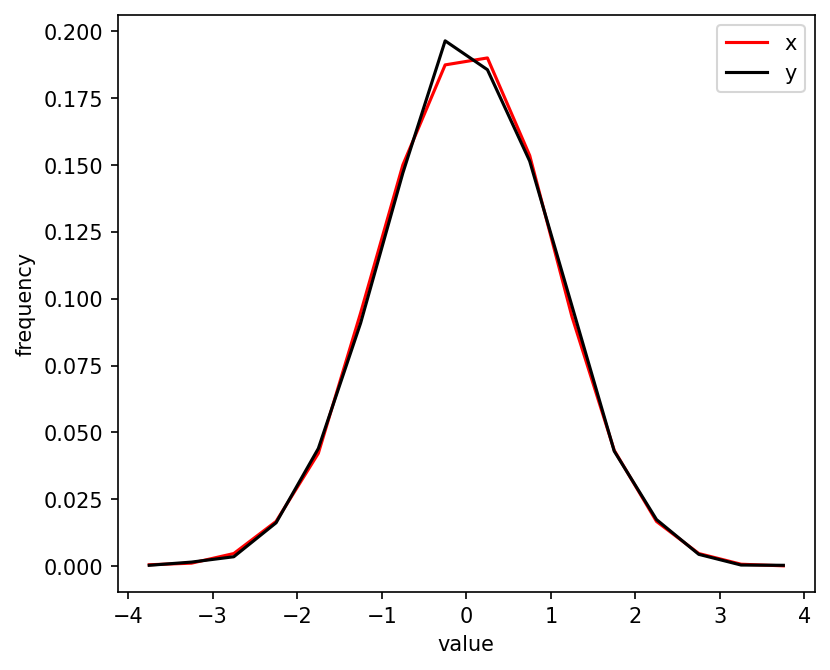

In [10]:
hx = np.histogram(x, xbins)
hy = np.histogram(y, xbins)

plt.figure()

xvals = hx[1][:-1]
fvalsx = hx[0].astype(float) / np.size(x)
fvalsy = hy[0].astype(float) / np.size(y)

plt.plot(xvals + xinc / 2, fvalsx, "r", label="x")
plt.plot(xvals + xinc / 2, fvalsy, "k", label="y")
plt.xlabel("value")
plt.ylabel("frequency")
plt.legend()

plt.show()

A PDF must integrate to 1.0 — meaning the *area under the curve* sums to 1,
not the y-values themselves. The integral includes the bin width as part of
the area, so we expect `sum(frequency) * bin_width = 1`.

In [11]:
[np.sum(fvalsx * xinc), np.sum(fvalsy * xinc)]

[np.float64(0.49999999999999994), np.float64(0.5)]

The integral sums to 0.5 for both variables — not 1. That's because we
divided by sample size but not by bin width. Scaling by `1 / (N * bin_width)`
gives us the proper PDF, which is now independent of our chosen bin width.

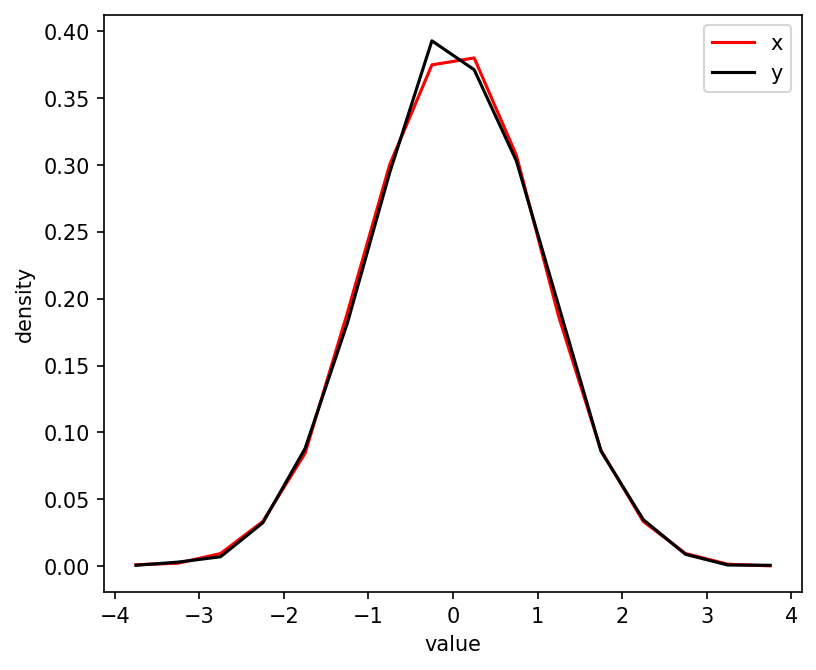

In [12]:
plt.figure()

xvals = hx[1][:-1]
fvalsx = hx[0].astype(float) / (np.size(x) * xinc)
fvalsy = hy[0].astype(float) / (np.size(y) * xinc)

plt.plot(xvals + xinc / 2, fvalsx, "r", label="x", linewidth=1.5)
plt.plot(xvals + xinc / 2, fvalsy, "k", label="y", linewidth=1.5)
plt.xlabel("value")
plt.ylabel("density")
plt.legend()

plt.show()

In [13]:
[np.sum(fvalsx) * xinc, np.sum(fvalsy) * xinc]

[np.float64(0.9999999999999999), np.float64(1.0)]

## Pro tip: kernel density estimation

The PDFs above aren't very pretty, so people often estimate smoothed versions
of them. There are many ways to smooth (we'll see more later in the course),
but specific to PDF estimation is the **kernel density estimator (KDE)**. It
computes each point as a weighted average of nearby data — the *kernel* sets
the weights so closer points count more. Below we use a Gaussian kernel.

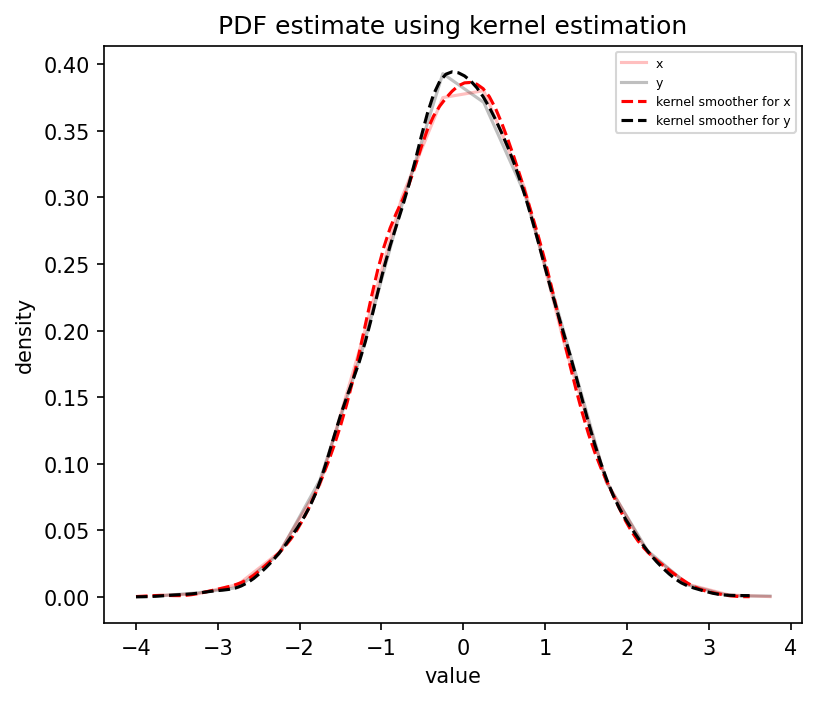

In [14]:
plt.figure()

xvals = hx[1][:-1]
fvalsx = hx[0].astype(float) / (np.size(x) * xinc)
fvalsy = hy[0].astype(float) / (np.size(y) * xinc)

plt.plot(xvals + xinc / 2, fvalsx, "r", label="x", linewidth=1.5, alpha=0.25)
plt.plot(xvals + xinc / 2, fvalsy, "k", label="y", linewidth=1.5, alpha=0.25)

xvals_smooth = np.linspace(np.min(xvals), np.max(xvals), 100)
kernel_x = stats.gaussian_kde(x)
plt.plot(
    xvals_smooth,
    kernel_x.pdf(xvals_smooth),
    linestyle="--",
    color="r",
    label="kernel smoother for x",
)
kernel_y = stats.gaussian_kde(y)
plt.plot(
    xvals_smooth,
    kernel_y.pdf(xvals_smooth),
    linestyle="--",
    color="k",
    label="kernel smoother for y",
)

plt.xlabel("value")
plt.ylabel("density")
plt.legend(fontsize=6)
plt.title("PDF estimate using kernel estimation")

plt.show()

## The cumulative density function (CDF)

The cumulative density function (CDF) is a close partner of the PDF, but it
shows the probability that the data take a value *less than or equal to* x.

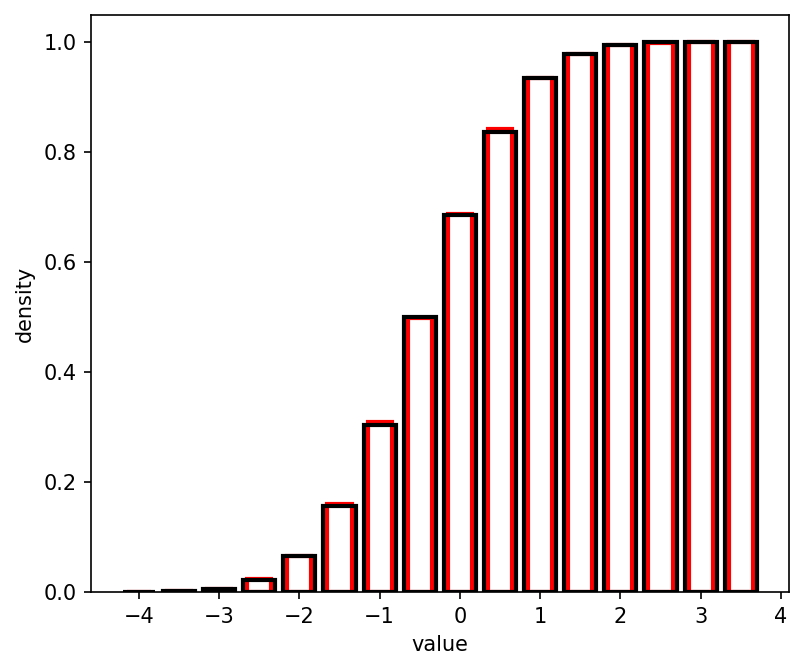

In [15]:
plt.figure()

hxx = np.cumsum(hx[0])
hyy = np.cumsum(hy[0])

plt.xlabel("value")
plt.ylabel("density")

plt.bar(
    hx[1][:-1],
    hxx.astype(float) / np.size(x),
    edgecolor="r",
    facecolor="none",
    width=0.3,
    linewidth=2,
)
plt.bar(
    hy[1][:-1],
    hyy.astype(float) / np.size(y),
    edgecolor="k",
    facecolor="none",
    width=0.4,
    linewidth=2,
)
plt.show()

## Wrap-up

We started from a scatter of raw values and built up to a probability density
function step by step:

1. A histogram counts how many values fall in each bin.
2. Dividing by sample size gives a **frequency** plot — comparable across
   samples of different size, but still bin-width dependent.
3. Dividing by *both* sample size and bin width gives a **density** — a true
   PDF whose area under the curve sums to 1.
4. Kernel density estimation provides a smoother PDF estimate from the same
   data.
5. The **CDF** is the running cumulative version of the PDF.